<div align="center">
    <h1> Control Barrier Functions in Semi-Automated Beverage Blending Equipment<br> 
    <h3> Samantha Becvar <br> University of Washington, Department of Mechanical Engineering Master's Program <br> A A/E E/M E 548 B <br> Prof. Karen Leung
</div>

## **----Section 0: Imports----**

In [2]:
import matplotlib.pyplot as plt
plt.ioff()
import ipynb
from ipynb.fs.full.Sec1_Build_The_Sys import *
from ipynb.fs.full.Sec2_Basic_PD_Controller import *
from ipynb.fs.full.Sec3_CLF_CBF_Filter import *
plt.ion()

## **----Section 4: Multiple Cup Sizes----**
In this section, I will simulate a blending profile for:
* a small sized cup
* a medium sized cup
* a large sized cup
* an extra large sizeed cup

In [3]:
''' Environment Definitions '''
# environment dimensions
env_dims_sim = jnp.array([
    [-10, 10],    # (x_min, x_max)
    [-1, 30]    # (y_min, y_max)
])
# black box dimensions
box_sizes_sim = jnp.array([
    [10, 1],    # bottom box, (width, height)
    [14, 6],    # top box, (width, height)
    [5, 32],    # left box, (width, height)
    [5, 32]    # right box, (width, height)
])
box_centers_sim = jnp.array([
    [0, -0.5],  # bottom box, (center_x, center_y)
    [0, 27],    # top box, (center_x, center_y) 
    [-7.5, 14], # left box, (center_x, center_y)
    [7.5, 14]  # right box, (center_x, center_y)
])

In [4]:
''' Cup Dimensions '''
small = jnp.array([
    4,  # bottom width
    6,  # top width
    0,  # center location
    8   # height
])
medium = jnp.array([
    5,  # bottom width
    7,  # top width
    0,  # center location
    9   # height
])
large = jnp.array([
    6,  # bottom width
    8,  # top width
    0,  # center location
    10  # height
])
xlarge = jnp.array([
    7,  # bottom width
    9,  # top width
    0,  # center location
    11  # height
])
cup_dims_sim = jnp.array([
    small,
    medium,
    large,
    xlarge
])
names = ["small", "medium", "large", "xlarge"]
cup_geom_sim = {}
for name, cup_dim in zip(names, cup_dims_sim):
    cup_geom_sim[name] = cup_geometry(cup_dim)


In [5]:
''' Set-Up for our Simulated System '''
# define our time
T = 12.0
DT = 0.01
# define our steps
N = int(T / DT)

# set-up our book keeping arrays, one for each simulation
logs = [
    {
        "times": [],
        "positions": [],
        "velocities": [],
        "u_nom": [],
        "u_safe": []
    }
    for _ in range(4)
]

''' Run our Simulated System'''
for i, (name, cup_dims) in enumerate(zip(names, cup_dims_sim)):
    print(f"\nRunning simulation: {name} cup")

    # reset our state for each simulation
    state = jnp.array([16.0, 0.0])
    home = state[0]

    # get cup geometry
    cup_geom = cup_geom_sim[name]

    log = logs[i]

    for k in range(N):
        # define our time
        t = k * DT

        # create our desired state for the time
        y_des, y_des_dot, enforce_cup = desired_state(
            cup_dims,
            home,
            t, 
            T)

        # crete our nominal control
        u_nom = clf_controller(
            state, 
            y_des,
            y_des_dot
        )

        # create our control
        u = cbf_filter(
            state,
            u_nom,
            cup_geom,
            enforce_cup
        )

        # update our state
        state = integrate(
            state,
            u,
            DT
        )
        
        # book keeping
        log["times"].append(t)
        log["positions"].append(state[0])
        log["velocities"].append(state[1])
        log["u_nom"].append(u_nom)
        log["u_safe"].append(u)


Running simulation: small cup

Running simulation: medium cup

Running simulation: large cup

Running simulation: xlarge cup


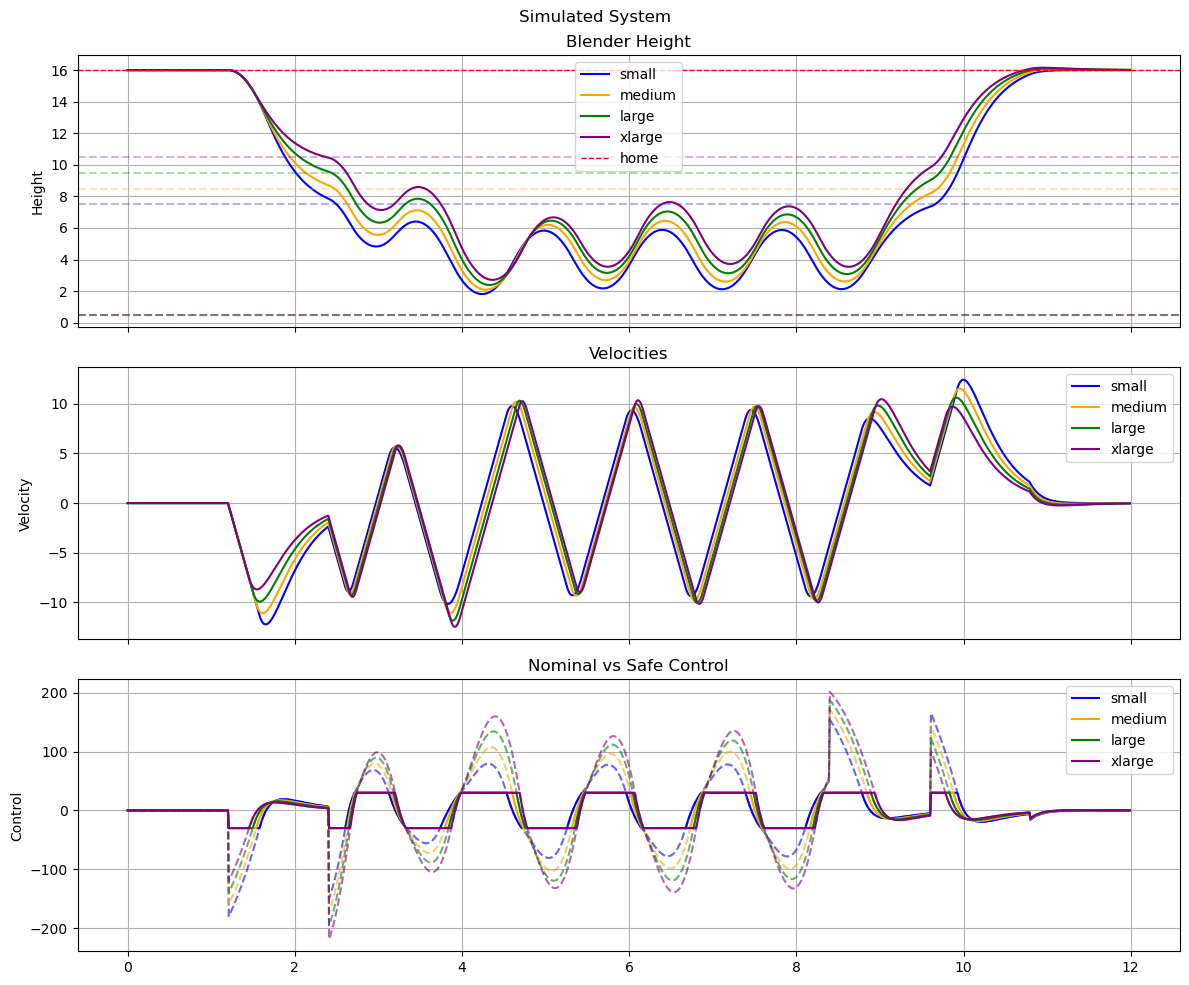

In [6]:
''' Create Plots of our Simulated System '''
# create our figure and axes
fig_sim, axs_sim = plt.subplots(
    3,
    1,
    figsize=(12, 10),
    sharex = True
)

names = ["small", "medium", "large", "xlarge"]
colors = ["blue", "orange", "green", "purple"]

''' Position Plot '''
for i, name in enumerate(names):
    log = logs[i]
    geom = cup_geom_sim[name]

    axs_sim[0].plot(
        log["times"],
        log["positions"],
        label=name,
        color=colors[i]
    )
    axs_sim[0].axhline(
        geom["cup_top_y"] - 0.5,
        linestyle="--",
        color = colors[i],
        alpha=0.3
    )
    axs_sim[0].axhline(
        geom["cup_bottom_y"] + 0.5,
        linestyle="--",
        color = colors[i],
        alpha=0.3
    )

axs_sim[0].set_ylabel("Height")
axs_sim[0].set_title("Blender Height")
axs_sim[0].axhline(
        home,
        color='red',
        linestyle='--',
        linewidth=1,
        label="home"
    )
axs_sim[0].legend()

''' Velocity Plot'''
for i, name in enumerate(names):
    log = logs[i]
    geom = cup_geom_sim[name]

    axs_sim[1].plot(
        log["times"],
        log["velocities"],
        label=name,
        color=colors[i]
    )

axs_sim[1].set_ylabel("Velocity")
axs_sim[1].set_title("Velocities")
axs_sim[1].legend()

''' Control Plot '''
for i, name in enumerate(names):
    axs_sim[2].plot(
        logs[i]["times"],
        logs[i]["u_nom"],
        linestyle="--",
        color=colors[i],
        alpha=0.6
    )

    axs_sim[2].plot(
        logs[i]["times"],
        logs[i]["u_safe"],
        color=colors[i],
        label=f"{name}"
    )

axs_sim[2].set_ylabel("Control")
axs_sim[2].set_title("Nominal vs Safe Control")
axs_sim[2].legend()

for ax in axs_sim:
    ax.grid(True)

fig_sim.suptitle("Simulated System")
plt.tight_layout()
plt.show()

In [ ]:
''' Animate the Simulated System '''
''' Definitions '''
# environment dimensions
env_dims_sim = jnp.array([
    [-10, 10],    # (x_min, x_max)
    [-1, 30]    # (y_min, y_max)
])
# black box dimensions
box_sizes_sim = jnp.array([
    [10, 1],    # bottom box, (width, height)
    [14, 6],    # top box, (width, height)
    [5, 32],    # left box, (width, height)
    [5, 32]    # right box, (width, height)
])
box_centers_sim = jnp.array([
    [0, -0.5],  # bottom box, (center_x, center_y)
    [0, 27],    # top box, (center_x, center_y) 
    [-7.5, 14], # left box, (center_x, center_y)
    [7.5, 14]  # right box, (center_x, center_y)
])

''' Create the Animation '''
def make_animation(cup_name, cup_dims, color, log):
    # create the figure and axis
    fig2_sim, ax2_sim = plt.subplots(figsize=(3, 4))
    # title our figure
    fig2_sim.suptitle(f"CLF-CBF Filter: {cup_name.capitalize()} Cup")

    def animate(frame):

        ax2_sim.clear()

        draw_environment(
            ax2_sim,
            env_dims_sim,
            box_sizes_sim,
            box_centers_sim,
            cup_dims,
            color
        )

        blender_height_sim = log["positions"][frame]
        blender(ax2_sim, blender_height_sim)

        ax2_sim.grid(False)
        ax2_sim.set_title(
            f"Time: {log["times"][frame]:.2f} s"
        )

    ani = FuncAnimation(
        fig2_sim,
        animate,
        frames=len(log["positions"]),
        interval=30
    )

    ani.save(
        f"{cup_name}_animation.gif",
        writer="pillow",
        fps=30
    )

    # return HTML(ani.to_jshtml())

#### Small Cup Blend Profile Animation

MovieWriter Pillow unavailable; using Pillow instead.


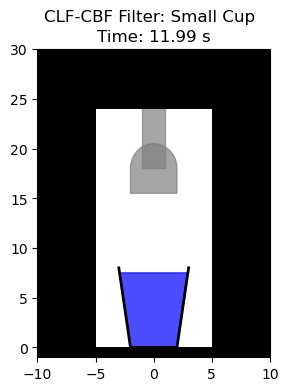

In [8]:
make_animation(names[0], cup_dims_sim[0], colors[0], logs[0])

#### Medium Cup Blend Profile Animation

MovieWriter Pillow unavailable; using Pillow instead.


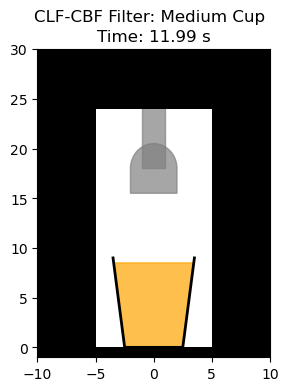

In [9]:
make_animation(names[1], cup_dims_sim[1], colors[1], logs[1])

#### Large Cup Blend Profile Animation

MovieWriter Pillow unavailable; using Pillow instead.


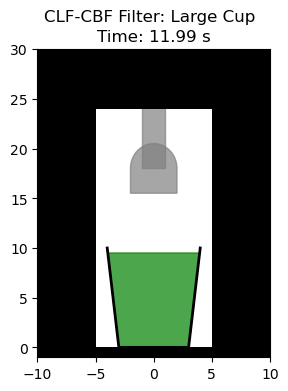

In [10]:
make_animation(names[2], cup_dims_sim[2], colors[2], logs[2])

#### Extra Large Cup Blend Profile Animation

MovieWriter Pillow unavailable; using Pillow instead.


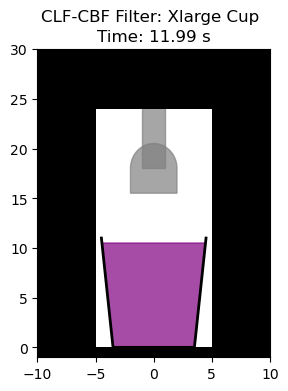

In [11]:
make_animation(names[3], cup_dims_sim[3], colors[3], logs[3])